## Fine-tuning and evaluation of the Exit Advisor

### Imports and setup

In [1]:
from openai import OpenAI
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

openai_key = os.getenv("OPENAI_API_KEY")
client = OpenAI()
print(openai_key[:5])

sk-pr


### loading the labeled dataset - sms_conversations.json

In [3]:
file_path = "C:\\AI_Projects\\Genai_final_project\\sms_conversations.json"

with open(file_path, "r", encoding="utf-8") as f:
    conversations = json.load(f)

print(f"Loaded {len(conversations)} conversations")


Loaded 15 conversations


### preparing the data set to an Open AI evaluation ready format

In [5]:
def build_exit_samples(conversations):
    samples = []

    for conv in conversations:
        turns = conv["turns"]

        for i, turn in enumerate(turns):
            # we only learn from labeled recruiter turns
            if turn["speaker"] != "recruiter":
                continue
            if turn["label"] is None:
                continue

            # skip first turn because there is no prior context
            if i == 0:
                continue

            previous_turn = turns[i - 1]

            # for the Exit Advisor we care about decision points
            # after a candidate message
            if previous_turn["speaker"] != "candidate":
                continue

            history = []
            for past_turn in turns[:i]:
                history.append({
                    "role": past_turn["speaker"],
                    "content": past_turn["text"]
                })

            samples.append({
                "conversation_id": conv["conversation_id"],
                "turn_id": turn["turn_id"],
                "chat_history": history,
                "expected_3way": turn["label"],
                "expected_exit": "end" if turn["label"] == "end" else "not_end"
            })

    return samples


exit_samples = build_exit_samples(conversations)

print(f"Total exit samples: {len(exit_samples)}")

Total exit samples: 44


In [6]:
# examining the dataset distribution

exit_counts = {}
three_way_counts = {}

for sample in exit_samples:
    e = sample["expected_exit"]
    t = sample["expected_3way"]

    exit_counts[e] = exit_counts.get(e, 0) + 1
    three_way_counts[t] = three_way_counts.get(t, 0) + 1

print("expected_exit counts:", exit_counts)
print("expected_3way counts:", three_way_counts)

expected_exit counts: {'not_end': 29, 'end': 15}
expected_3way counts: {'schedule': 19, 'end': 15, 'continue': 10}


### Spliting the dataset to train and test 80/20

In [7]:
import random

# 1. get unique conversation ids
conversation_ids = list(set(sample["conversation_id"] for sample in exit_samples))

# 2. shuffle them
random.seed(42)
random.shuffle(conversation_ids)

# 3. split 80/20
split_index = int(0.8 * len(conversation_ids))

train_ids = conversation_ids[:split_index]
test_ids = conversation_ids[split_index:]

# 4. assign samples to train/test
train_samples = [s for s in exit_samples if s["conversation_id"] in train_ids]
test_samples = [s for s in exit_samples if s["conversation_id"] in test_ids]

# 5. print summary
print("Total conversations:", len(conversation_ids))
print("Train conversations:", len(train_ids))
print("Test conversations:", len(test_ids))

print("Train samples:", len(train_samples))
print("Test samples:", len(test_samples))

Total conversations: 15
Train conversations: 12
Test conversations: 3
Train samples: 33
Test samples: 11


In [8]:
# Checking the distribution in test and train samples

train_exit_count = 0
train_not_end_count = 0

for sample in train_samples:
    if sample["expected_exit"] == "end":
        train_exit_count += 1
    else:
        train_not_end_count += 1

print("Train expected_exit distribution:")
print("end:", train_exit_count)
print("not_end:", train_not_end_count)


test_exit_count = 0
test_not_end_count = 0

for sample in test_samples:
    if sample["expected_exit"] == "end":
        test_exit_count += 1
    else:
        test_not_end_count += 1

print("\nTest expected_exit distribution:")
print("end:", test_exit_count)
print("not_end:", test_not_end_count)

Train expected_exit distribution:
end: 12
not_end: 21

Test expected_exit distribution:
end: 3
not_end: 8


In [11]:
# Perpare the data sets to conform to the open ai platform format

exit_advisor_instructions = """
You are the Exit Advisor in a recruiting chatbot for a Python Developer position.

Your task:
Decide whether the chatbot should END the conversation now or CONTINUE the conversation.

Return:
END or CONTINUE

Return END only when the conversation should clearly be concluded, for example:
- The candidate says they are not interested
- The candidate asks to stop being contacted
- The candidate says they found another job
- The interaction has naturally concluded after scheduling or final closure

Return CONTINUE when:
- the candidate is still engaged
- the candidate asks questions
- the candidate wants more information
- the candidate wants to schedule or continue the process
- there is any reasonable doubt

Rules:
- Prefer CONTINUE if unsure.
- Return only END or CONTINUE.
- Do not explain your answer.
""".strip()

def format_chat_history(chat_history):
    lines = []
    for msg in chat_history:
        role = msg["role"].upper()
        lines.append(f"{role}: {msg['content']}")
    return "\n".join(lines)


def build_train_and_test_datasets(train_samples, test_samples):

    train_data = []
    test_data = []

    # ---- TRAIN (fine-tuning format) ----
    for sample in train_samples:
        conversation_text = format_chat_history(sample["chat_history"])

        user_input = (
            "Conversation so far:\n\n"
            f"{conversation_text}\n\n"
            "Should the chatbot END the conversation now or CONTINUE?\n"
            "Return only END or CONTINUE."
        )

        label = "END" if sample["expected_exit"] == "end" else "CONTINUE"

        train_data.append({
            "messages": [
                {"role": "system", "content": exit_advisor_instructions},
                {"role": "user", "content": user_input},
                {"role": "assistant", "content": label}
            ]
        })

    # ---- TEST (eval format) ----
    for sample in test_samples:
        conversation_text = format_chat_history(sample["chat_history"])

        user_input = (
            "Conversation so far:\n\n"
            f"{conversation_text}\n\n"
            "Should the chatbot END the conversation now or CONTINUE?\n"
            "Return only END or CONTINUE."
        )

        label = "END" if sample["expected_exit"] == "end" else "CONTINUE"

        test_data.append({
            "item": {
                "input": user_input,
                "correct_output": label
            }
        })

    return train_data, test_data


train_data, test_data = build_train_and_test_datasets(train_samples, test_samples)

print("Train examples:", len(train_data))
print("Test examples:", len(test_data))

train_data[0], test_data[0]

Train examples: 33
Test examples: 11


({'messages': [{'role': 'system',
    'content': 'You are the Exit Advisor in a recruiting chatbot for a Python Developer position.\n\nYour task:\nDecide whether the chatbot should END the conversation now or CONTINUE the conversation.\n\nReturn:\nEND or CONTINUE\n\nReturn END only when the conversation should clearly be concluded, for example:\n- The candidate says they are not interested\n- The candidate asks to stop being contacted\n- The candidate says they found another job\n- The interaction has naturally concluded after scheduling or final closure\n\nReturn CONTINUE when:\n- the candidate is still engaged\n- the candidate asks questions\n- the candidate wants more information\n- the candidate wants to schedule or continue the process\n- there is any reasonable doubt\n\nRules:\n- Prefer CONTINUE if unsure.\n- Return only END or CONTINUE.\n- Do not explain your answer.'},
   {'role': 'user',
    'content': 'Conversation so far:\n\nRECRUITER: Hi, thanks for submitting your applicat

In [13]:
# Creating the 2 files Test and Train

train_file_path = "exit_advisor_training.jsonl"
test_file_path = "exit_advisor_test.jsonl"

with open(train_file_path, "w", encoding="utf-8") as f:
    for item in train_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

with open(test_file_path, "w", encoding="utf-8") as f:
    for item in test_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")


In [14]:
# Checking the files

with open(train_file_path, "r", encoding="utf-8") as f:
    first_train_line = f.readline()

with open(test_file_path, "r", encoding="utf-8") as f:
    first_test_line = f.readline()

print("First train line:")
print(first_train_line)

print("\nFirst test line:")
print(first_test_line)

First train line:
{"messages": [{"role": "system", "content": "You are the Exit Advisor in a recruiting chatbot for a Python Developer position.\n\nYour task:\nDecide whether the chatbot should END the conversation now or CONTINUE the conversation.\n\nReturn:\nEND or CONTINUE\n\nReturn END only when the conversation should clearly be concluded, for example:\n- The candidate says they are not interested\n- The candidate asks to stop being contacted\n- The candidate says they found another job\n- The interaction has naturally concluded after scheduling or final closure\n\nReturn CONTINUE when:\n- the candidate is still engaged\n- the candidate asks questions\n- the candidate wants more information\n- the candidate wants to schedule or continue the process\n- there is any reasonable doubt\n\nRules:\n- Prefer CONTINUE if unsure.\n- Return only END or CONTINUE.\n- Do not explain your answer."}, {"role": "user", "content": "Conversation so far:\n\nRECRUITER: Hi, thanks for submitting your ap

### Uploading the files to the OpenAI platform

In [15]:
# Uploading the files to the OpenAI platform

train_file = client.files.create(
    file=open(train_file_path, "rb"),
    purpose="fine-tune"
)

test_file = client.files.create(
    file=open(test_file_path, "rb"),
    purpose="fine-tune"   
)


print("Train file ID:", train_file.id)
print("Test file ID:", test_file.id)

Train file ID: file-WafZwEnxoqsZ2guR1buAqx
Test file ID: file-3LJeaX1bCQy8yiw7R4qbZT


### Fine tuning the model

In [17]:
fine_tune = client.fine_tuning.jobs.create(
  model="gpt-4.1-2025-04-14",
  training_file=train_file.id,
  method={"type":"supervised"}
  
)


print(fine_tune)
print("Status:", fine_tune.status)

FineTuningJob(id='ftjob-gp3cRCQlw4blz50i5LJG04eb', created_at=1776773848, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs='auto'), model='gpt-4.1-2025-04-14', object='fine_tuning.job', organization_id='org-gkIjXGoSAJfNbsBhtsB8zCDe', result_files=[], seed=61459520, status='validating_files', trained_tokens=None, training_file='file-WafZwEnxoqsZ2guR1buAqx', validation_file=None, estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs='auto'))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=None)
Status: validating_f

In [76]:
fine_tune.id        # job ID (used to track)


'ftjob-gp3cRCQlw4blz50i5LJG04eb'

In [77]:
fine_tune.model     # base model

'gpt-4.1-2025-04-14'

In [79]:
job_id = fine_tune.id
job = client.fine_tuning.jobs.retrieve(job_id)
print("Fine tuned Model:", job.fine_tuned_model)

Fine tuned Model: ft:gpt-4.1-2025-04-14:personal::DX4VJRRt


In [27]:
# Trying to use the fine tuned model once

my_fine_tuned_model = job.fine_tuned_model
instructions = exit_advisor_instructions

review = "Thank you, it is no longer relevant for me"

response = client.responses.create(
    model=my_fine_tuned_model,
    input=[
        {"role": "developer", "content": instructions},
        {"role": "user", "content": review}
    ]
)

print(response.output_text)

END


### Creating the EVAL definition

In [31]:
exit_eval = client.evals.create(
    name="Exit Advisor END vs CONTINUE",
    data_source_config={
        "type": "custom",
        "item_schema": {
            "type": "object",
            "properties": {
                "input": {"type": "string"},
                "correct_output": {"type": "string"},
            },
            "required": ["input", "correct_output"],
        },
        "include_sample_schema": True,
    },
    testing_criteria=[
        {
            "type": "string_check",
            "name": "Match output to human label",
            "input": "{{ sample.output_text }}",
            "operation": "eq",
            "reference": "{{ item.correct_output }}"
        }
    ],
)

print(exit_eval)
print(exit_eval.id)

EvalCreateResponse(id='eval_69e794cbc5388191a9539ea00d46c546', created_at=1776784587, data_source_config=EvalCustomDataSourceConfig(schema_={'type': 'object', 'properties': {'item': {'type': 'object', 'properties': {'input': {'type': 'string'}, 'correct_output': {'type': 'string'}}, 'required': ['input', 'correct_output']}, 'sample': {'type': 'object', 'properties': {'model': {'type': 'string'}, 'choices': {'type': 'array', 'items': {'type': 'object', 'properties': {'message': {'type': 'object', 'properties': {'role': {'type': 'string', 'enum': ['assistant']}, 'content': {'type': ['string', 'array', 'null']}, 'refusal': {'type': ['boolean', 'null']}, 'tool_calls': {'type': ['array', 'null'], 'items': {'type': 'object', 'properties': {'type': {'type': 'string', 'enum': ['function']}, 'function': {'type': 'object', 'properties': {'name': {'type': 'string'}, 'arguments': {'type': 'string'}}, 'required': ['name', 'arguments']}, 'id': {'type': 'string'}}, 'required': ['type', 'function', 'i

### EVAL run with the general model on the test data

In [47]:
baseline_run = client.evals.runs.create(
    exit_eval.id,
    name="Exit Advisor - baseline gpt-4.1 retry",
    data_source={
        "type": "completions",
        "model": "gpt-4.1-2025-04-14",
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "system", "content": exit_advisor_instructions},
                {"role": "user", "content": "{{item.input}}"}
            ],
        },
        "source": {
            "type": "file_content",
            "content": test_data
        },
        "sampling_params": {
            "temperature": 0
        }
    },
)

print(baseline_run)
print("Baseline run ID:", baseline_run.id)
print("Baseline status:", baseline_run.status)

RunCreateResponse(id='evalrun_69e79dd460c081918e19e18adef37e43', created_at=1776786900, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileContent(content=[SourceFileContentContent(item={'input': "Conversation so far:\n\nRECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\n\nShould the chatbot END the conversation now or CONTINUE?\nReturn only END or CONTINUE.", 'correct_output': 'CONTINUE'}, sample=None), SourceFileContentContent(item={'input': "Conversation so far:\n\nRECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\nRECRUITER: Our engineering manager can interview you Wednesday at 10\u202fAM or Thursday at 2\u202fPM. Which works best?\nCANDIDATE: 

### Retrieving the results

In [48]:
run_retrieve = client.evals.runs.retrieve(
    eval_id = exit_eval.id,
    run_id = baseline_run.id
)

print("Status:", run_retrieve.status)
print("Result counts:", run_retrieve.result_counts)
print("Report URL:", run_retrieve.report_url)


Status: completed
Result counts: ResultCounts(errored=0, failed=2, passed=9, total=11)
Report URL: https://platform.openai.com/evaluations/eval_69e794cbc5388191a9539ea00d46c546?project_id=proj_8zitnyhiCTnafpLngsEEtrd7&run_id=evalrun_69e79dd460c081918e19e18adef37e43


### EVAL run with the Fine-Tuned model on the test data

In [49]:
ft_run = client.evals.runs.create(
    exit_eval.id,
    name="Exit Advisor - Fine-Tuned Model run",
    data_source={
        "type": "completions",
        "model": my_fine_tuned_model,
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "system", "content": exit_advisor_instructions},
                {"role": "user", "content": "{{item.input}}"}
            ],
        },
        "source": {
            "type": "file_content",
            "content": test_data
        },
        "sampling_params": {
            "temperature": 0
        }
    },
)

print(ft_run)
print("Baseline run ID:", ft_run.id)
print("Baseline status:", ft_run.status)

RunCreateResponse(id='evalrun_69e79e151c948191af444979b1de422b', created_at=1776786965, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileContent(content=[SourceFileContentContent(item={'input': "Conversation so far:\n\nRECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\n\nShould the chatbot END the conversation now or CONTINUE?\nReturn only END or CONTINUE.", 'correct_output': 'CONTINUE'}, sample=None), SourceFileContentContent(item={'input': "Conversation so far:\n\nRECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\nRECRUITER: Our engineering manager can interview you Wednesday at 10\u202fAM or Thursday at 2\u202fPM. Which works best?\nCANDIDATE: 

### Retrieving the results of the fine tune run

In [97]:
ft_run_retrieve = client.evals.runs.retrieve(
    eval_id = exit_eval.id,
    run_id = ft_run.id
)

print("Status:", ft_run_retrieve.status)
print("Result counts:", ft_run_retrieve.result_counts)
print("Report URL:", ft_run_retrieve.report_url)


Status: completed
Result counts: ResultCounts(errored=0, failed=1, passed=10, total=11)
Report URL: https://platform.openai.com/evaluations/eval_69e794cbc5388191a9539ea00d46c546?project_id=proj_8zitnyhiCTnafpLngsEEtrd7&run_id=evalrun_69e79e151c948191af444979b1de422b


### The fine tuned model improved the results from 2 failed to 1 failed

In [53]:
# Retrieve all items for the eval run

items = client.evals.runs.output_items.list(
    eval_id=exit_eval.id,
    run_id=ft_run.id
    )


items_list = list(items)

In [54]:
# Extract ground truth and predictions
y_true = [item.datasource_item['correct_output'] for item in items]
y_pred = [item.sample.output[0].content.strip() for item in items]

In [55]:
# Compute metrics accuracy_score
print('accuracy_score')
print(accuracy_score(y_true, y_pred))

accuracy_score
0.9090909090909091


In [56]:
labels = sorted(set(y_true) | set(y_pred))
print(labels)

['CONTINUE', 'END']


In [57]:
cm = confusion_matrix(y_true, y_pred, labels=labels)


df_cm = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion Matrix:\n")
print(df_cm)

Confusion Matrix:

          CONTINUE  END
CONTINUE         7    1
END              0    3


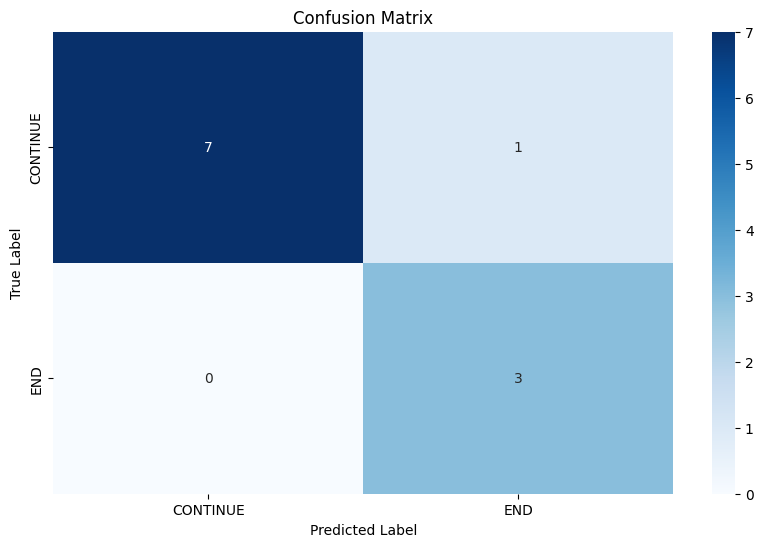

In [58]:
for idx, label in enumerate(labels):
    TP = cm[idx, idx]
    FP = cm[:, idx].sum() - TP
    FN = cm[idx, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

plt.figure(figsize=(10, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

### Checking and analyzing the failed cases

In [59]:
failed_items = client.evals.runs.output_items.list(
    eval_id=exit_eval.id,
    run_id=ft_run.id,
    status="fail"
)

print(failed_items)

SyncCursorPage[OutputItemListResponse](data=[OutputItemListResponse(id='outputitem_69e79e162ca88191954b7eb136505078', created_at=1776786966, datasource_item={'input': "Conversation so far:\n\nRECRUITER: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?\nCANDIDATE: I have three years' experience with Django and Flask.\nRECRUITER: Do you have any questions of your own?\nCANDIDATE: Could you share more about the company's cloud technologies?\nRECRUITER: We currently deploy to AWS using Docker and ECS.\nCANDIDATE: Sounds great! I'd be happy to schedule a meeting\n\nShould the chatbot END the conversation now or CONTINUE?\nReturn only END or CONTINUE.", 'correct_output': 'CONTINUE'}, datasource_item_id=5, eval_id='eval_69e794cbc5388191a9539ea00d46c546', object='eval.run.output_item', results=[Result(name='Match output to human label-78ef2e7d-eb23-4659-b776-f957f7aedd50', passed=False, score=0.0, sample=None, type=No

In [60]:
for i, failed in enumerate(failed_items.data, start=1):
    print("=" * 100)
    print(f"FAILED CASE {i}")
    print("=" * 100)

    print("\nINPUT:\n")
    print(failed.datasource_item["input"])

    print("\nEXPECTED:\n")
    print(failed.datasource_item["correct_output"])

    print("\nMODEL OUTPUT:\n")
    print(failed.sample.output[0].content)

    print("\nRESULTS:\n")
    print(failed.results)
    print()

FAILED CASE 1

INPUT:

Conversation so far:

RECRUITER: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
CANDIDATE: I have three years' experience with Django and Flask.
RECRUITER: Do you have any questions of your own?
CANDIDATE: Could you share more about the company's cloud technologies?
RECRUITER: We currently deploy to AWS using Docker and ECS.
CANDIDATE: Sounds great! I'd be happy to schedule a meeting

Should the chatbot END the conversation now or CONTINUE?
Return only END or CONTINUE.

EXPECTED:

CONTINUE

MODEL OUTPUT:

END

RESULTS:

[Result(name='Match output to human label-78ef2e7d-eb23-4659-b776-f957f7aedd50', passed=False, score=0.0, sample=None, type=None)]



### I decided to add 5 new examples to the train data to improve the training of the model

In [71]:
additional_train_examples = [
    {
        "messages": [
            {"role": "system", "content": exit_advisor_instructions},
            {
                "role": "user",
                "content": (
                    "Conversation so far:\n\n"
                    "RECRUITER: Do you have any questions of your own?\n"
                    "CANDIDATE: Could you share more about the company's cloud technologies?\n"
                    "RECRUITER: We currently deploy to AWS using Docker and ECS.\n"
                    "CANDIDATE: Sounds great! I'd be happy to schedule a meeting\n\n"
                    "Should the chatbot END the conversation now or CONTINUE?\n"
                    "Return only END or CONTINUE."
                )
            },
            {"role": "assistant", "content": "CONTINUE"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": exit_advisor_instructions},
            {
                "role": "user",
                "content": (
                    "Conversation so far:\n\n"
                    "CANDIDATE: Yes, I would like to schedule an interview.\n\n"
                    "Should the chatbot END the conversation now or CONTINUE?\n"
                    "Return only END or CONTINUE."
                )
            },
            {"role": "assistant", "content": "CONTINUE"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": exit_advisor_instructions},
            {
                "role": "user",
                "content": (
                    "Conversation so far:\n\n"
                    "CANDIDATE: That sounds perfect, let's set up a time.\n\n"
                    "Should the chatbot END the conversation now or CONTINUE?\n"
                    "Return only END or CONTINUE."
                )
            },
            {"role": "assistant", "content": "CONTINUE"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": exit_advisor_instructions},
            {
                "role": "user",
                "content": (
                    "Conversation so far:\n\n"
                    "CANDIDATE: Thanks, that sounds interesting. I'd like to move forward.\n\n"
                    "Should the chatbot END the conversation now or CONTINUE?\n"
                    "Return only END or CONTINUE."
                )
            },
            {"role": "assistant", "content": "CONTINUE"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": exit_advisor_instructions},
            {
                "role": "user",
                "content": (
                    "Conversation so far:\n\n"
                    "RECRUITER: Great, your interview is confirmed for Monday at 10 AM.\n"
                    "CANDIDATE: Sounds great, thank you. See you then.\n\n"
                    "Should the chatbot END the conversation now or CONTINUE?\n"
                    "Return only END or CONTINUE."
                )
            },
            {"role": "assistant", "content": "END"}
        ]
    }
]

augmented_train_data = train_data + additional_train_examples

print("Original train examples:", len(train_data))
print("Added examples:", len(additional_train_examples))
print("Augmented train examples:", len(augmented_train_data))

Original train examples: 33
Added examples: 5
Augmented train examples: 38


In [72]:
augmented_train_file_path = "exit_advisor_training_augmented.jsonl"

with open(augmented_train_file_path, "w", encoding="utf-8") as f:
    for item in augmented_train_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Saved:", augmented_train_file_path)

Saved: exit_advisor_training_augmented.jsonl


In [73]:
with open(augmented_train_file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Number of lines:", len(lines))
print("Last example:")
print(lines[-1])

Number of lines: 38
Last example:
{"messages": [{"role": "system", "content": "You are the Exit Advisor in a recruiting chatbot for a Python Developer position.\n\nYour task:\nDecide whether the chatbot should END the conversation now or CONTINUE the conversation.\n\nReturn:\nEND or CONTINUE\n\nReturn END only when the conversation should clearly be concluded, for example:\n- The candidate says they are not interested\n- The candidate asks to stop being contacted\n- The candidate says they found another job\n- The interaction has naturally concluded after scheduling or final closure\n\nReturn CONTINUE when:\n- the candidate is still engaged\n- the candidate asks questions\n- the candidate wants more information\n- the candidate wants to schedule or continue the process\n- there is any reasonable doubt\n\nRules:\n- Prefer CONTINUE if unsure.\n- Return only END or CONTINUE.\n- Do not explain your answer."}, {"role": "user", "content": "Conversation so far:\n\nRECRUITER: Great, your inter

### Uploading the new train file

In [74]:
augmented_train_file = client.files.create(
    file=open(augmented_train_file_path, "rb"),
    purpose="fine-tune"
)

print("New train file ID:", augmented_train_file.id)

New train file ID: file-KvygQbJzeB5mmNrHDtLGjL


### Fine tuning the model on the augmented train data

In [75]:
new_fine_tune = client.fine_tuning.jobs.create(
  model="gpt-4.1-2025-04-14",
  training_file = augmented_train_file.id,
  method={"type":"supervised"}
  
)


print(new_fine_tune)
print("Status:", new_fine_tune.status)

FineTuningJob(id='ftjob-D5XSiuPL65FfE3GI4S49HcXe', created_at=1776790716, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs='auto'), model='gpt-4.1-2025-04-14', object='fine_tuning.job', organization_id='org-gkIjXGoSAJfNbsBhtsB8zCDe', result_files=[], seed=1715518565, status='validating_files', trained_tokens=None, training_file='file-KvygQbJzeB5mmNrHDtLGjL', validation_file=None, estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs='auto'))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=None)
Status: validating

In [80]:
new_fine_tune.status

'validating_files'

In [81]:
new_fine_tune.id

'ftjob-D5XSiuPL65FfE3GI4S49HcXe'

In [82]:
job = client.fine_tuning.jobs.retrieve(new_fine_tune.id)
    
print("New Fine tuned model:", job.fine_tuned_model)

New Fine tuned model: ft:gpt-4.1-2025-04-14:personal::DX9OaOX9


In [83]:
my_new_fine_tune_model = job.fine_tuned_model

### EVAL run with the new Fine-Tuned model on the augmented test data

In [85]:
new_ft_run = client.evals.runs.create(
    exit_eval.id,
    name="Exit Advisor - Fine-Tuned Model new run",
    data_source={
        "type": "completions",
        "model": my_new_fine_tune_model,
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "system", "content": exit_advisor_instructions},
                {"role": "user", "content": "{{item.input}}"}
            ],
        },
        "source": {
            "type": "file_content",
            "content": test_data
        },
        "sampling_params": {
            "temperature": 0
        }
    },
)

print(new_ft_run)
print("Baseline run ID:", new_ft_run.id)
print("Baseline status:", new_ft_run.status)

RunCreateResponse(id='evalrun_69e7bd46b8848191aff99063cffb837b', created_at=1776794950, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileContent(content=[SourceFileContentContent(item={'input': "Conversation so far:\n\nRECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\n\nShould the chatbot END the conversation now or CONTINUE?\nReturn only END or CONTINUE.", 'correct_output': 'CONTINUE'}, sample=None), SourceFileContentContent(item={'input': "Conversation so far:\n\nRECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\nRECRUITER: Our engineering manager can interview you Wednesday at 10\u202fAM or Thursday at 2\u202fPM. Which works best?\nCANDIDATE: 

In [89]:
new_ft_run_retrieve = client.evals.runs.retrieve(
    eval_id = exit_eval.id,
    run_id = new_ft_run.id
)

print("Status:", new_ft_run_retrieve.status)
print("Result counts:", new_ft_run_retrieve.result_counts)
print("Report URL:", new_ft_run_retrieve.report_url)


Status: completed
Result counts: ResultCounts(errored=0, failed=0, passed=11, total=11)
Report URL: https://platform.openai.com/evaluations/eval_69e794cbc5388191a9539ea00d46c546?project_id=proj_8zitnyhiCTnafpLngsEEtrd7&run_id=evalrun_69e7bd46b8848191aff99063cffb837b


In [90]:
items = client.evals.runs.output_items.list(
    eval_id = exit_eval.id,
    run_id = new_ft_run.id
    )


items_list = list(items)

# Extract ground truth and predictions
y_true = [item.datasource_item['correct_output'] for item in items]
y_pred = [item.sample.output[0].content.strip() for item in items]

In [91]:
# Compute metrics accuracy_score
print('accuracy_score')
print(accuracy_score(y_true, y_pred))

accuracy_score
1.0


### The added examples to the train data improved the results of the new fine tuned model on the test data - accuracy 100%

### We will use this new fine tuned model for the exit advisor

In [99]:
my_new_fine_tune_model

'ft:gpt-4.1-2025-04-14:personal::DX9OaOX9'